# Ejercicio 1: prueba de hipótesis para una media

Una empresa siderúrgica produce barras con una media de 115 cm. 
Para poder probar la H0 que la media de la producción de un cierto mes es la misma, se tomó una muestra aleatoria de 20 barras obteniéndose una media de 118 cm. y un desvío estándar igual a 20. 
Verificar si es posible aceptar, que la media sigue siendo la misma para un nivel de significación del 5%.



- H0: μ = 115
- H1: μ ≠ 115
- n = 20
- x̄ = 118
- s = 20
- α = 0.05

Si no logro rechazar la hipotesis nula voy a dejar todo como esta, como es de igual contra distinto es una prueba de dos colas.
La muestra es chica y encima NO conozco el DESVIO POBLACIONAL. tengo solo el desvio estandar que es muestral (S), NO es SIGMA.
Vamos a usar una T de student con 19 grados de libertad

Media hipotética bajo H0 (mu0): 115
Media muestral (x̄): 118
Desviación estándar muestral (s): 20
Tamaño de muestra (n): 20
Grados de libertad: 19
Estadístico t calculado: 0.6708
Valor p: 0.5104
Valor crítico t: ±2.0930
Decisión: no se rechaza H0. No hay evidencia suficiente para afirmar que la media cambió.


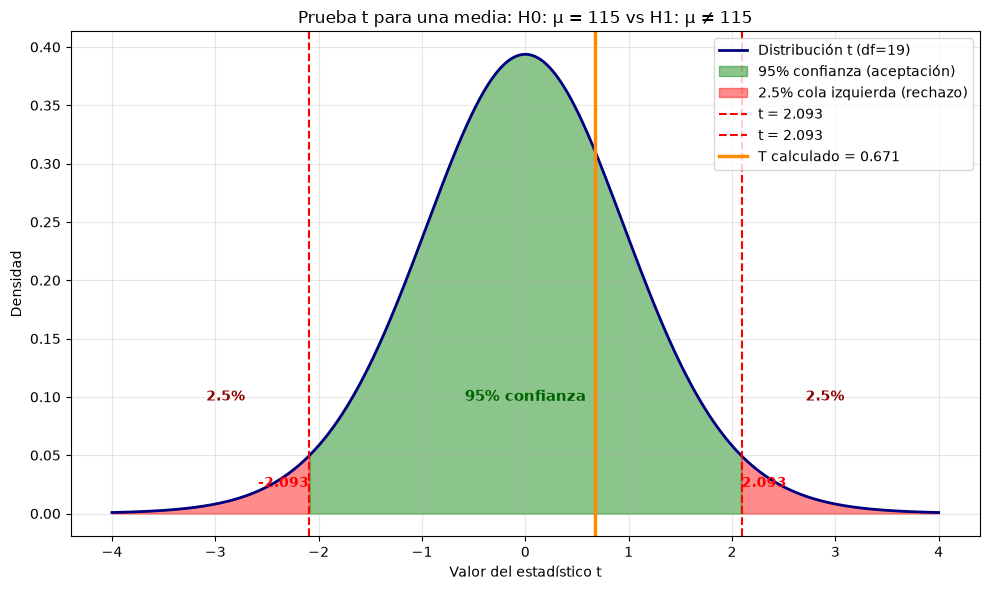

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos del problema
mu0 = 115
x_barra = 118
s = 20
n = 20
alpha = 0.05

# Hipótesis
# H0: mu = 115
# H1: mu != 115

# Estadístico t
T = (x_barra - mu0) / (s / np.sqrt(n))
gl = n - 1
p_valor = 2 * stats.t.sf(abs(T), df=gl)

# Valor crítico para una prueba bilateral
critico = stats.t.ppf(1 - alpha / 2, df=gl)

print(f"Media hipotética bajo H0 (mu0): {mu0}")
print(f"Media muestral (x̄): {x_barra}")
print(f"Desviación estándar muestral (s): {s}")
print(f"Tamaño de muestra (n): {n}")
print(f"Grados de libertad: {gl}")
print(f"Estadístico t calculado: {T:.4f}")
print(f"Valor p: {p_valor:.4f}")
print(f"Valor crítico t: ±{critico:.4f}")

if p_valor < alpha:
    print("Decisión: se rechaza H0. Hay evidencia para afirmar que la media cambió.")
else:
    print("Decisión: no se rechaza H0. No hay evidencia suficiente para afirmar que la media cambió.")

# Gráfica de la distribución t con las tres zonas: confianza, cola izquierda y cola derecha
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=gl)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, color='navy', linewidth=2, label='Distribución t (df=19)')

# Zona central: nivel de confianza = 1 - alpha = 95%
region_central = (x >= -critico) & (x <= critico)
ax.fill_between(x, y, where=region_central, color='green', alpha=0.45, label='95% confianza (aceptación)')

# Cola izquierda: alpha/2 = 2.5%
region_izq = x <= -critico
ax.fill_between(x, y, where=region_izq, color='red', alpha=0.45, label='2.5% cola izquierda (rechazo)')

# Cola derecha: alpha/2 = 2.5%
region_der = x >= critico
ax.fill_between(x, y, where=region_der, color='red', alpha=0.45)

# Límites de rechazo con valores de t
ax.axvline(-critico, color='red', linestyle='--', linewidth=1.5, label=f't = {critico:.3f}')
ax.axvline(critico, color='red', linestyle='--', linewidth=1.5, label=f't = {critico:.3f}')

# Estadístico calculado
ax.axvline(T, color='darkorange', linestyle='-', linewidth=2.5, label=f'T calculado = {T:.3f}')

# Etiquetas de zonas
ax.text(0, 0.1, '95% confianza', ha='center', va='center', fontsize=11, color='darkgreen', fontweight='bold')
ax.text(-2.9, 0.1, '2.5%', ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')
ax.text(2.9, 0.1, '2.5%', ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

# Etiquetas con los valores exactos en cada límite
ax.text(-critico, 0.02, f'-{critico:.3f}', color='red', fontsize=10, fontweight='bold', ha='right', va='bottom')
ax.text(critico, 0.02, f'{critico:.3f}', color='red', fontsize=10, fontweight='bold', ha='left', va='bottom')

ax.set_title('Prueba t para una media: H0: μ = 115 vs H1: μ ≠ 115')
ax.set_xlabel('Valor del estadístico t')
ax.set_ylabel('Densidad')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


El estadistico T es el que me marca que cae en zona de no rechazo 
T = (115-118)/(20/√ 20) = 0.671